In [67]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
from scipy.special import comb

In [68]:
def bernstein_poly(i, n, t):
    """Calcule le polynôme de Bernstein."""
    return comb(n, i) * (t ** (n - i)) * (1 - t) ** i


def bezier_curve(control_points, n_times=50):
    """Génère les points d'une courbe de Bézier lissée."""
    n_points = len(control_points)
    if n_points < 2:
        return np.array([]), np.array([])

    t = np.linspace(0.0, 1.0, n_times)
    # create polynomials
    polynomial_array = np.array(
        [bernstein_poly(i, n_points - 1, t) for i in range(n_points)]
    )

    # multiply with control points
    x_vals = np.dot(control_points[:, 0], polynomial_array)
    y_vals = np.dot(control_points[:, 1], polynomial_array)

    return x_vals, y_vals


In [69]:

ANNOTATIONS_JSON = "../datasets/forbin_dataset/val_fold_0_single.json"
IMAGES_DIR = '../datasets/forbin_dataset/'



In [70]:
def get_bezier_boundary(bezier_pts, num_pts=25):
    """
    Reproduit la logique du code DeepSolo :
    Transforme 8 points de contrôle en une boundary (contour) et une polyline (centre).
    """
    # 1. Reshape en (8, 2) -> 4 points haut, 4 points bas
    bezier_pts = np.array(bezier_pts).reshape(-1, 2)

    # 2. Préparation pour le calcul matriciel (format 4x4 comme dans ton code)
    # On sépare haut (top) et bas (bottom)
    # Le code DeepSolo transpose et reshape pour appliquer Bernstein
    ctrl_pts = bezier_pts.reshape(2, 4, 2).transpose(0, 2, 1).reshape(4, 4)

    # 3. Échantillonnage de la courbe (u de 0 à 1)
    u = np.linspace(0, 1, num_pts)

    # Polynôme de Bézier cubique (Bernstein n=3)
    # Expression : (1-u)^3*P0 + 3u(1-u)^2*P1 + 3u^2(1-u)*P2 + u^3*P3
    boundary_points = (
        np.outer((1 - u) ** 3, ctrl_pts[:, 0])
        + np.outer(3 * u * ((1 - u) ** 2), ctrl_pts[:, 1])
        + np.outer(3 * (u**2) * (1 - u), ctrl_pts[:, 2])
        + np.outer(u**3, ctrl_pts[:, 3])
    )

    # 4. Construction de la boundary fermée (Haut + Bas inversé)
    # boundary_points contient [x_top, y_top, x_bottom, y_bottom]
    top_line = boundary_points[:, :2]
    bottom_line = boundary_points[:, 2:][::-1, :]  # Inverser pour fermer le polygone

    boundary = np.vstack([top_line, bottom_line])

    # 5. Calcul de la polyline (Ligne médiane)
    polyline = (top_line + bottom_line[::-1, :]) / 2

    return boundary, polyline, bezier_pts


# --- Fonction de Visualisation avec COCO API ---


def visualize_deepsolo_with_coco(coco_api, img_id, img_dir, num_pts=25):
    # Charger les infos image
    img_info = coco_api.loadImgs(img_id)[0]
    img_path = os.path.join(img_dir, img_info["file_name"])

    img = Image.open(img_path)
    ann_ids = coco_api.getAnnIds(imgIds=img_id)
    anns = coco_api.loadAnns(ann_ids)

    fig, ax = plt.subplots(figsize=(15, 10))
    ax.imshow(img)

    for ann in anns:
        # if "bezier_pts" not in ann:
        #     continue

        # Calcul des éléments DeepSolo
        boundary, polyline, ctrl_pts = get_bezier_boundary(ann["bezier_pts"], num_pts)

        # A. Affichage de la Boundary (Contour Vert)
        ax.plot(
            boundary[:, 0],
            boundary[:, 1],
            "g-",
            alpha=0.7,
            linewidth=1.5,
            label="Boundary" if ann == anns[0] else "",
        )
        ax.fill(boundary[:, 0], boundary[:, 1], "g", alpha=0.1)
        ax.scatter(
            boundary[:, 0],
            boundary[:, 1],
            color="g",
            s=15,
            zorder=4,
            label="Boundary" if ann == anns[0] else "",
        )

        # B. Affichage de la Polyline (Centre Rouge)
        ax.plot(
            polyline[:, 0],
            polyline[:, 1],
            "r--",
            linewidth=2,
            label="Polyline (Center)" if ann == anns[0] else "",
        )
        ax.scatter(
            polyline[:, 0],
            polyline[:, 1],
            color="red",
            s=20,
            marker="o",
            zorder=11,
            label="Polyline Points (25)" if ann == anns[0] else "",
        )

        # C. Affichage des points de contrôle originaux (Points Jaunes)
        ax.scatter(
            ctrl_pts[:, 0],
            ctrl_pts[:, 1],
            color="yellow",
            s=30,
            zorder=5,
            label="Control Pts" if ann == anns[0] else "",
        )

        # D. Texte
        if "text" in ann:
            ax.text(
                ctrl_pts[0, 0],
                ctrl_pts[0, 1] - 15,
                ann["text"],
                color="white",
                fontsize=9,
                bbox=dict(facecolor="red", alpha=0.5),
            )

    plt.title(f"DeepSolo Logic Visualization - Image ID: {img_id}")
    plt.legend(loc="upper right")
    plt.axis("off")
    plt.savefig("img.png")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Affichage de l'image ID aléatoire : 158


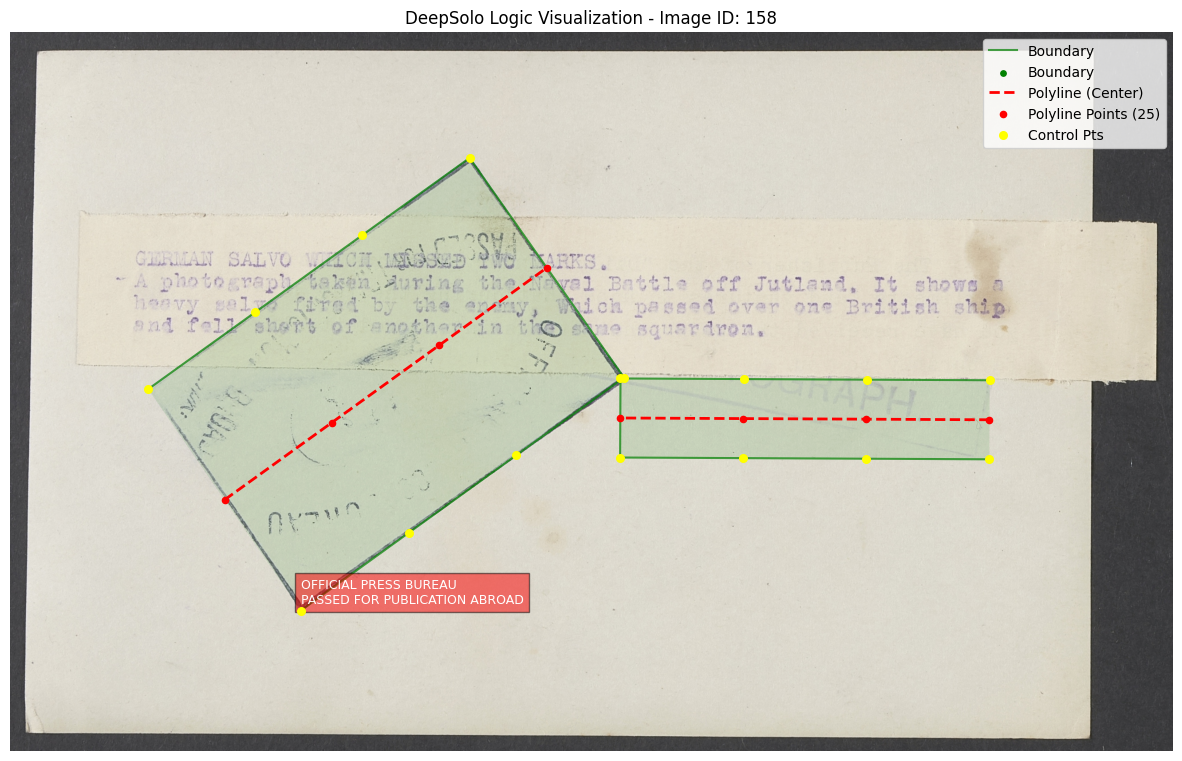

In [83]:
try:
    coco = COCO(ANNOTATIONS_JSON)
except Exception as e:
    print(f"Erreur lors du chargement du JSON : {e}")
    # Pour tester sans fichier, on simule une ID
    coco = None


# 3. Choisir une image à afficher

# OPTION A : Choisir une ID d'image spécifique (ex: 0)
my_img_id = 554
# my_img_id = 551
# my_img_id = 521
my_img_id = 158


# OPTION B : Choisir une image au hasard parmi celles qui ont des annotations
import random

img_ids_with_anns = coco.getImgIds()  # Récupère toutes les IDs

# my_img_id = random.choice(img_ids_with_anns)
print(f"Affichage de l'image ID aléatoire : {my_img_id}")

# for id in img_ids_with_anns:
visualize_deepsolo_with_coco(coco, my_img_id, IMAGES_DIR, num_pts=4)